# IR performance simulation with hyperparameter tuning

Same simulation as `ir-performance-simulation.ipynb`, but the models that showed
performance degradation with increasing imbalance ratio — Random Forest,
HistGradientBoosting, GBM (sklearn) and LightGBM — are now trained with
hyperparameter tuning using successive halving (`HalvingRandomSearchCV`, with the
number of trees as the limiting resource, mirroring `functions/cv.py`).

XGBoost, CatBoost and Logistic Regression were fine with default hyperparameters,
so we leave them as is for speed.

The hyperparameter search spaces come from `configs/hyperparams.py`
(`hyperparam_ensemble_dict`). There is no dictionary for HistGradientBoosting in
the config, so we adapt the sklearn GBM one to HistGradientBoosting's parameter
names in this notebook.

## Imports

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform

from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.experimental import enable_halving_search_cv
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    HalvingRandomSearchCV,
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from configs.hyperparams import hyperparam_ensemble_dict

In [2]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

## Training

For each imbalance ratio, the tuned models first go through a successive halving
search (optimising ROC-AUC, same settings as `train_model` in `functions/cv.py`),
and the best estimator is then cross-validated with the same folds used for the
untuned models, so the plots remain comparable.

Note that tuning and cross-validating on the same data introduces a small
optimistic bias, but it applies equally to all tuned models and we care about the
trend with the imbalance ratio, not the absolute scores. A nested CV would be
prohibitively slow at the largest imbalance ratios.

Heads up: the search fits ~120 models per classifier per imbalance ratio. At
IR=5000 (1M rows) this takes a while, especially for GBM (sklearn), which is
single-threaded.

In [3]:
random_state = 42

# Reduced from 1000: at IR=5000 that produced 5M rows and killed RF.
# 200 minority samples is enough to detect degradation across all classifiers.
minority_samples = 200

imbalance_ratios = [10, 100, 500, 1000, 5000]

n_splits = 3

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "log_loss": "neg_log_loss",
}

classifiers = {
    # No n_estimators / max_iter on the tuned models: successive halving
    # controls the number of trees as the limiting resource.
    "Random Forest": RandomForestClassifier(
        random_state=random_state,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        random_state=random_state,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=random_state,
    ),
    "LightGBM": LGBMClassifier(
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        random_state=random_state,
        verbose=0,
    ),
    "GBM (sklearn)": GradientBoostingClassifier(
        random_state=random_state,
    ),
    # Logistic regression needs scaling; wrapped in a pipeline.
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=random_state)),
    ]),
}

# HistGradientBoosting is not in configs/hyperparams.py; this adapts gbm_params
# to its parameter names (no subsample/min_samples_split in HistGB).
hist_params = {
    "max_depth": (1, 2, 3, 4, 8, None),
    "learning_rate": uniform(0, 1),
    "min_samples_leaf": randint(2, 20),
    "max_leaf_nodes": (15, 31, 63, 127, None),
    "l2_regularization": uniform(0, 1),
}

# Models to tune: search space and the halving resource
# (HistGB calls its n_estimators max_iter).
tuned_models = {
    "Random Forest": (hyperparam_ensemble_dict["rf_params"], "n_estimators"),
    "HistGradientBoosting": (hist_params, "max_iter"),
    "LightGBM": (hyperparam_ensemble_dict["lgbm_params"], "n_estimators"),
    "GBM (sklearn)": (hyperparam_ensemble_dict["gbm_params"], "n_estimators"),
}

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def tune_model(estimator, params, X, y, resource="n_estimators"):
    # Same search settings as train_model in functions/cv.py.
    search = HalvingRandomSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_candidates="exhaust",  # the number of candidates to evaluate at the first iteration
        factor=3,  # only a third of the candidates are promoted
        resource=resource,  # the limiting resource (number of trees)
        max_resources=1000,
        min_resources=10,
        scoring="roc_auc",
        cv=cv,
        random_state=random_state,
        n_jobs=-1,
    )
    search.fit(X, y)
    return search


results = {name: [] for name in classifiers}
best_params = {name: [] for name in tuned_models}

for ir in imbalance_ratios:
    majority_samples = minority_samples * ir
    total_samples = majority_samples + minority_samples

    weights = [majority_samples / total_samples, minority_samples / total_samples]

    X, y = make_classification(
        n_samples=total_samples,
        n_features=20,
        n_informative=10,
        n_redundant=5,
        n_repeated=0,
        n_classes=2,
        weights=weights,
        flip_y=0,
        class_sep=0.7,
        random_state=random_state,
    )

    for name, clf in classifiers.items():
        if name in tuned_models:
            params, resource = tuned_models[name]
            search = tune_model(clone(clf), params, X, y, resource=resource)
            model = search.best_estimator_
            best_params[name].append(search.best_params_)
            tag = "tuned"
        else:
            model = clf
            tag = "default"

        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        results[name].append(scores)
        print(
            f"IR {ir:4d}:1 | {name:25s} | {tag:7s} | "
            f"ROC-AUC = {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}"
        )

IR   10:1 | Random Forest             | tuned   | ROC-AUC = 0.9277 ± 0.0251
IR   10:1 | XGBoost                   | default | ROC-AUC = 0.9490 ± 0.0123
IR   10:1 | HistGradientBoosting      | tuned   | ROC-AUC = 0.9557 ± 0.0148
IR   10:1 | LightGBM                  | tuned   | ROC-AUC = 0.9592 ± 0.0114
IR   10:1 | CatBoost                  | default | ROC-AUC = 0.9706 ± 0.0093
IR   10:1 | GBM (sklearn)             | tuned   | ROC-AUC = 0.9460 ± 0.0195
IR   10:1 | Logistic Regression       | default | ROC-AUC = 0.8180 ± 0.0403


/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread

IR  100:1 | Random Forest             | tuned   | ROC-AUC = 0.9089 ± 0.0164
IR  100:1 | XGBoost                   | default | ROC-AUC = 0.9496 ± 0.0020
IR  100:1 | HistGradientBoosting      | tuned   | ROC-AUC = 0.9354 ± 0.0085
IR  100:1 | LightGBM                  | tuned   | ROC-AUC = 0.9602 ± 0.0030
IR  100:1 | CatBoost                  | default | ROC-AUC = 0.9389 ± 0.0099
IR  100:1 | GBM (sklearn)             | tuned   | ROC-AUC = 0.9425 ± 0.0050
IR  100:1 | Logistic Regression       | default | ROC-AUC = 0.8345 ± 0.0191
IR  500:1 | Random Forest             | tuned   | ROC-AUC = 0.9429 ± 0.0089
IR  500:1 | XGBoost                   | default | ROC-AUC = 0.9484 ± 0.0091
IR  500:1 | HistGradientBoosting      | tuned   | ROC-AUC = 0.9598 ± 0.0064
IR  500:1 | LightGBM                  | tuned   | ROC-AUC = 0.9555 ± 0.0061
IR  500:1 | CatBoost                  | default | ROC-AUC = 0.9458 ± 0.0104
IR  500:1 | GBM (sklearn)             | tuned   | ROC-AUC = 0.9432 ± 0.0075
IR  500:1 | 

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


IR 5000:1 | Random Forest             | tuned   | ROC-AUC = 0.8905 ± 0.0122
IR 5000:1 | XGBoost                   | default | ROC-AUC = 0.9468 ± 0.0162
IR 5000:1 | HistGradientBoosting      | tuned   | ROC-AUC = 0.9490 ± 0.0249
IR 5000:1 | LightGBM                  | tuned   | ROC-AUC = 0.9149 ± 0.0150
IR 5000:1 | CatBoost                  | default | ROC-AUC = 0.9420 ± 0.0203
IR 5000:1 | GBM (sklearn)             | tuned   | ROC-AUC = 0.7792 ± 0.0386
IR 5000:1 | Logistic Regression       | default | ROC-AUC = 0.7834 ± 0.0398


## Best hyperparameters

In [4]:
# Best hyperparameters found per imbalance ratio
for name, params_per_ir in best_params.items():
    print(name)
    for ir, params in zip(imbalance_ratios, params_per_ir):
        print(f"  IR {ir:4d}:1 | {params}")
    print()

Random Forest
  IR   10:1 | {'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 810}
  IR  100:1 | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 17, 'min_samples_split': 17, 'n_estimators': 810}
  IR  500:1 | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 17, 'min_samples_split': 17, 'n_estimators': 810}
  IR 1000:1 | {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 19, 'min_samples_split': 13, 'n_estimators': 810}
  IR 5000:1 | {'max_depth': 8, 'max_features': 0.25, 'min_samples_leaf': 16, 'min_samples_split': 14, 'n_estimators': 810}

HistGradientBoosting
  IR   10:1 | {'l2_regularization': np.float64(0.5133261686923929), 'learning_rate': np.float64(0.2332280724245278), 'max_depth': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 18, 'max_iter': 810}
  IR  100:1 | {'l2_regularization': np.float64(0.6243540481337932), 'learning_rate': np.float64(0.295633685837714), 'max_depth': 8, 'max_

## Prepare results

In [5]:
metrics = ["roc_auc", "average_precision", "log_loss"]

stats = {
    name: {metric: {"mean": [], "std": []} for metric in metrics}
    for name in classifiers
}

for name, clf_results in results.items():
    for scores in clf_results:
        for metric in metrics:
            sign = -1 if metric == "log_loss" else 1
            vals = sign * scores[f"test_{metric}"]
            stats[name][metric]["mean"].append(vals.mean())
            stats[name][metric]["std"].append(vals.std())

In [6]:
GROUP_1 = ["XGBoost", "Random Forest", "Logistic Regression", ]
GROUP_2 = ["CatBoost", "GBM (sklearn)", "LightGBM", "HistGradientBoosting"]

def plot_metric(metric, ylabel, title):
    marker_cycle = ["o", "s", "^", "D", "v", "P"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, group in zip(axes, [GROUP_1, GROUP_2]):
        for name, marker in zip(group, marker_cycle):
            clf_stats = stats[name]
            means = np.array(clf_stats[metric]["mean"])
            stds = np.array(clf_stats[metric]["std"])
            line, = ax.plot(imbalance_ratios, means, marker=marker, label=name)
            ax.fill_between(
                imbalance_ratios, means - stds, means + stds,
                alpha=0.2, color=line.get_color(),
            )
        ax.set_xscale("log")
        ax.set_xticks(imbalance_ratios)
        ax.set_xticklabels(imbalance_ratios)
        ax.set_xlabel("Imbalance Ratio (Majority : Minority)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle(title, y=1.02)
    axes[0].set_title("Model performance")
    axes[1].set_title("Model performance")
    plt.tight_layout()
    plt.show()

## Plot ROC-AUC

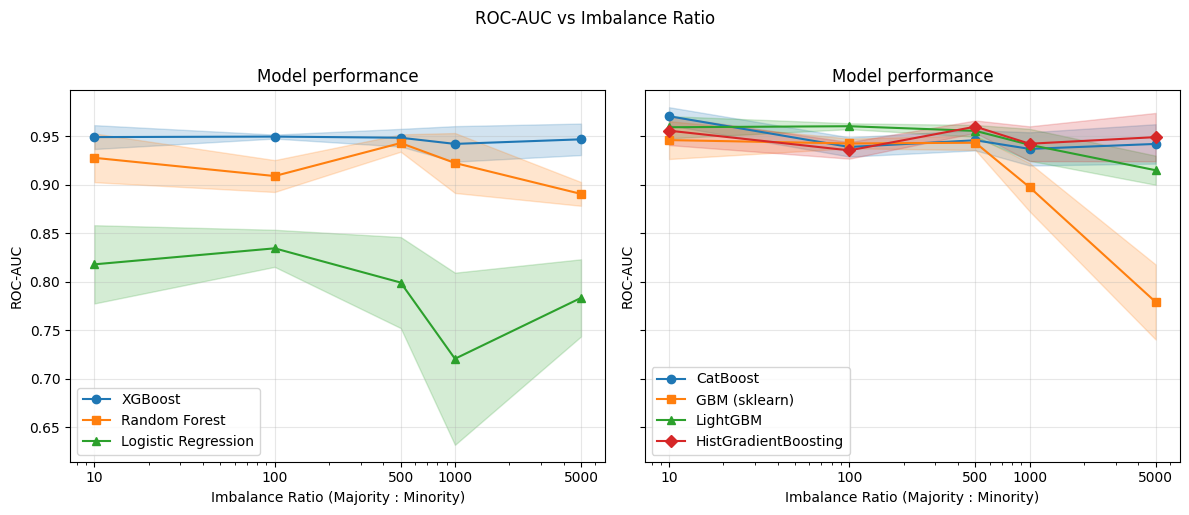

In [7]:
plot_metric("roc_auc", "ROC-AUC", "ROC-AUC vs Imbalance Ratio")

## Plot Average Precision

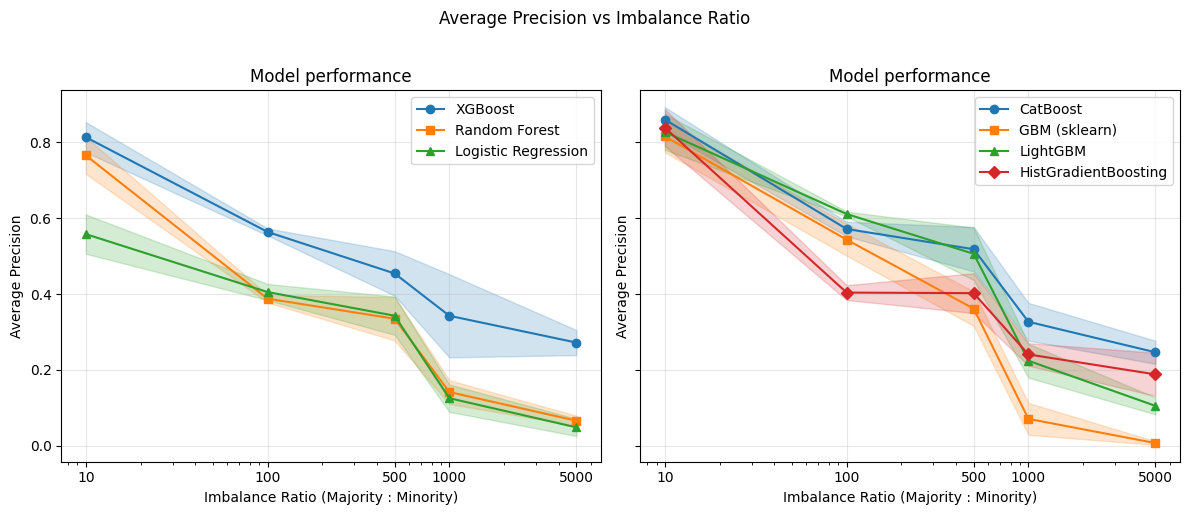

In [8]:
plot_metric("average_precision", "Average Precision", "Average Precision vs Imbalance Ratio")

## Plot Log Loss

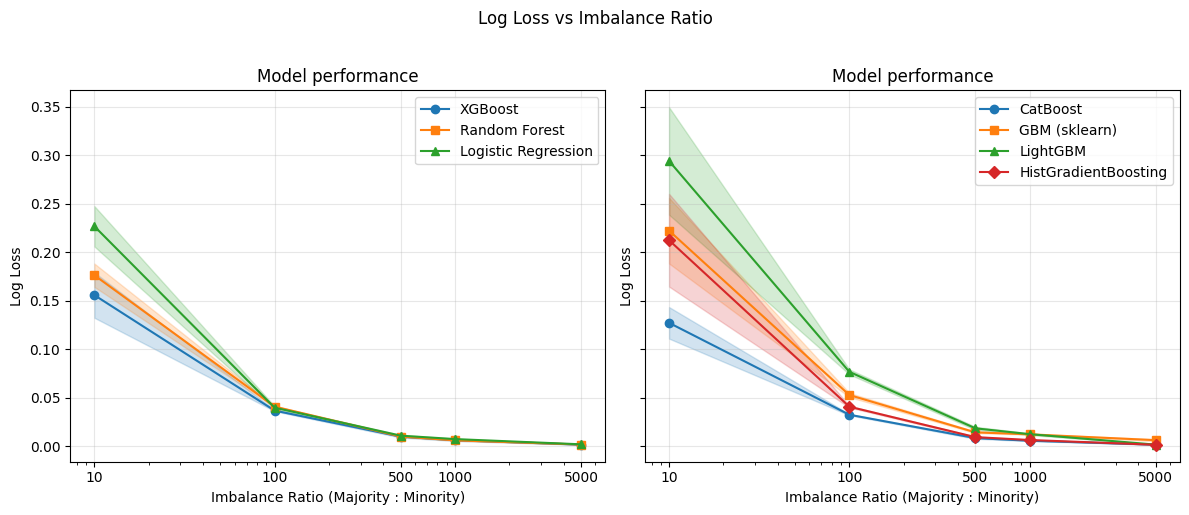

In [9]:
plot_metric("log_loss", "Log Loss", "Log Loss vs Imbalance Ratio")